### Import libraries and load the dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

df = pd.read_csv("../data/train_updated.csv")
df.head()

,ProfileID,ApplicantYears,AnnualEarnings,RequestedSum,TrustMetric,WorkDuration,ActiveAccounts,OfferRate,RepayPeriod,DebtFactor,QualificationLevel,WorkCategory,RelationshipStatus,OwnsProperty,FamilyObligation,FundUseCase,JointApplicant,RiskFlag
0,DRIRC89L0T,18,137576,209136,846,26,2,10.470,60,0.810,High School,Self-employed,Single,Yes,No,Business,No,0
1,TS0FIUNHNU,47,57194,5970,748,30,2,19.720,36,0.730,High School,Unemployed,Divorced,No,Yes,Education,No,0
2,I0YR284A1V,26,84328,95065,453,7,2,24.250,12,0.450,Master's,Self-employed,Married,No,No,Other,Yes,0
3,WB1T7NQV8A,53,49795,229582,533,107,3,14.440,60,0.170,Bachelor's,Self-employed,Single,Yes,No,Auto,Yes,1
4,J6GU9M4G1Z,49,115450,22072,840,0,4,24.480,12,0.110,Bachelor's,Part-time,Single,No,Yes,Education,Yes,0


### Check dataset shape, data types, and missing values

In [2]:
print("Shape:", df.shape)
df.info()
df.isnull().sum()

Shape: (204277, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204277 entries, 0 to 204276
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ProfileID           204277 non-null  object 
 1   ApplicantYears      204277 non-null  int64  
 2   AnnualEarnings      204277 non-null  int64  
 3   RequestedSum        204277 non-null  int64  
 4   TrustMetric         204277 non-null  int64  
 5   WorkDuration        204277 non-null  int64  
 6   ActiveAccounts      204277 non-null  int64  
 7   OfferRate           204277 non-null  float64
 8   RepayPeriod         204277 non-null  int64  
 9   DebtFactor          204277 non-null  float64
 10  QualificationLevel  204277 non-null  object 
 11  WorkCategory        204277 non-null  object 
 12  RelationshipStatus  204277 non-null  object 
 13  OwnsProperty        204277 non-null  object 
 14  FamilyObligation    204277 non-null  object 
 15  FundUseCase   

ProfileID             0
ApplicantYears        0
AnnualEarnings        0
RequestedSum          0
TrustMetric           0
WorkDuration          0
ActiveAccounts        0
OfferRate             0
RepayPeriod           0
DebtFactor            0
QualificationLevel    0
WorkCategory          0
RelationshipStatus    0
OwnsProperty          0
FamilyObligation      0
FundUseCase           0
JointApplicant        0
RiskFlag              0
dtype: int64

### Calculate RiskFlag class proportions

In [3]:
df['RiskFlag'].value_counts(normalize=True) * 100

RiskFlag
0   88.372
1   11.628
Name: proportion, dtype: float64

### Plot RiskFlag distribution to visualize class imbalance

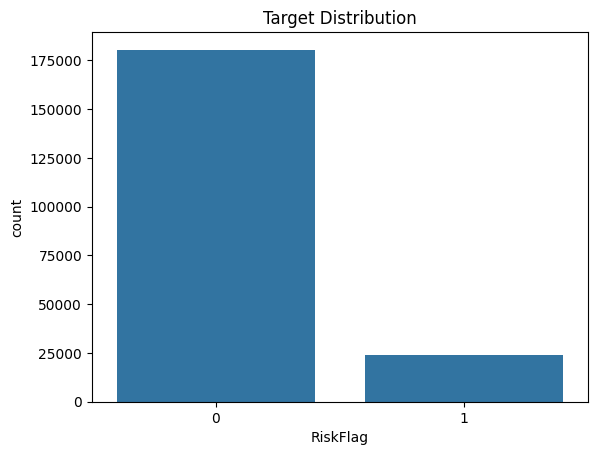

In [4]:
sns.countplot(data=df, x='RiskFlag')
plt.title("Target Distribution")
plt.show()

### Visualize numerical feature distributions (histograms)

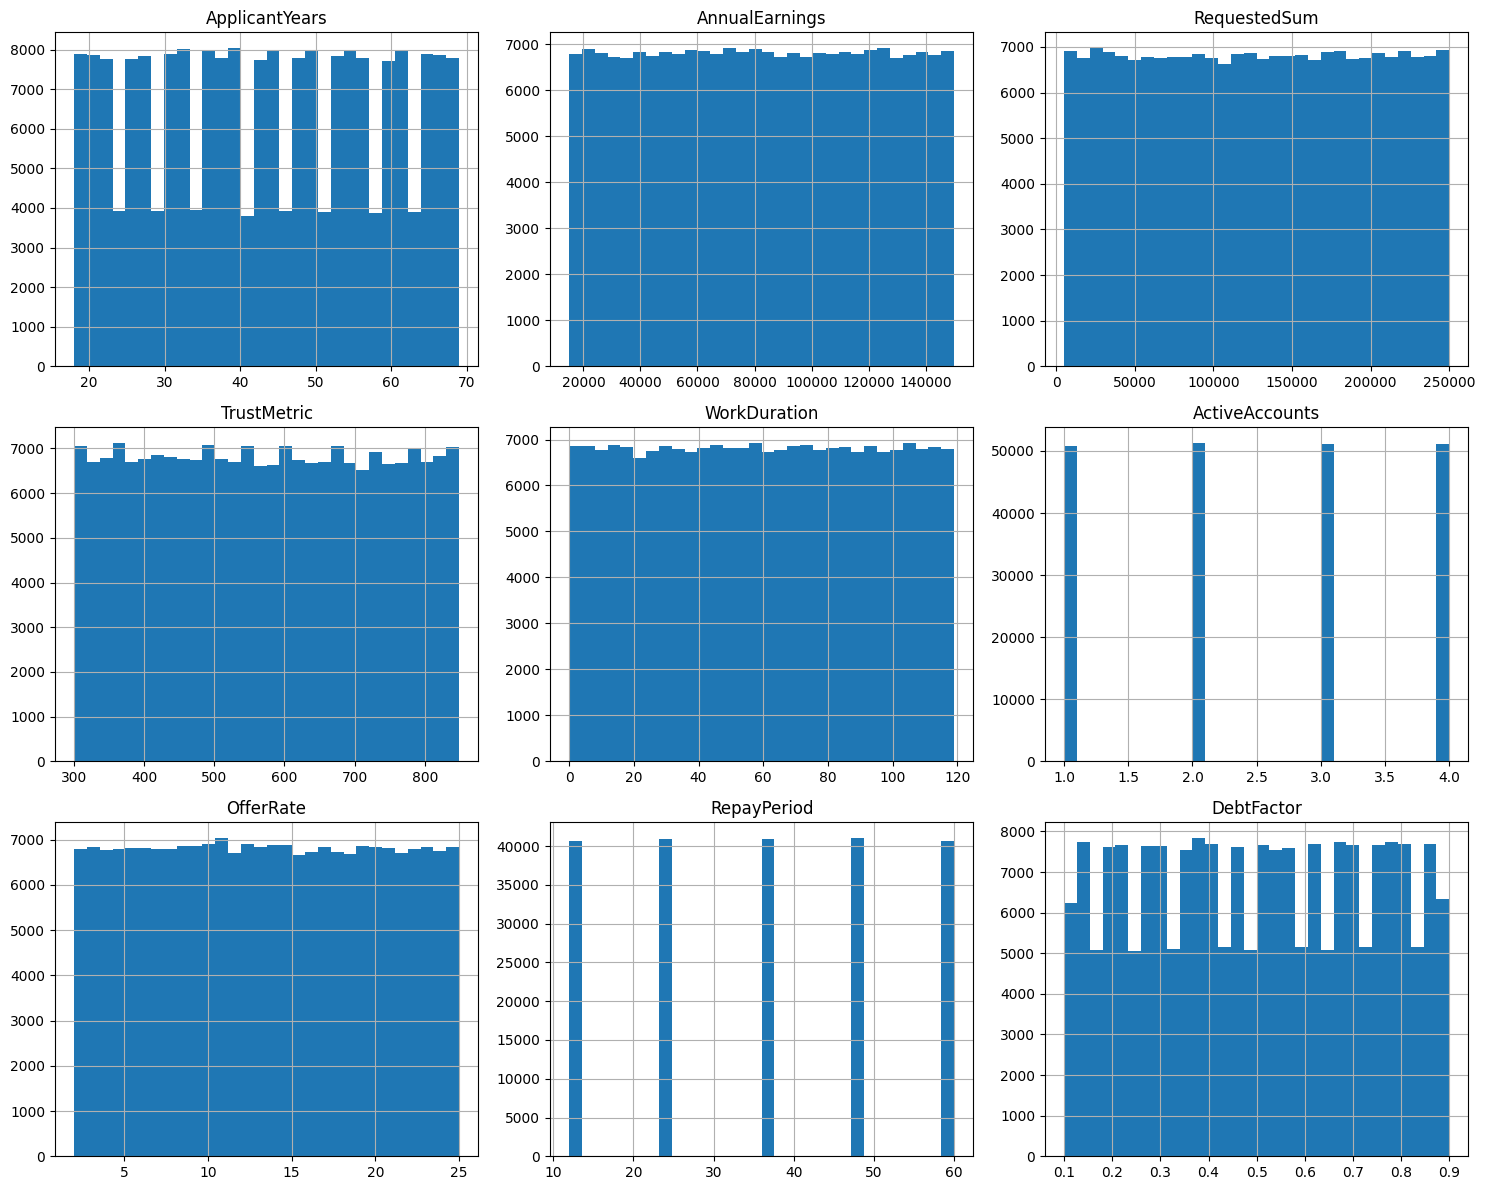

In [5]:
numerical = [
    "ApplicantYears", "AnnualEarnings", "RequestedSum", "TrustMetric",
    "WorkDuration", "ActiveAccounts", "OfferRate", "RepayPeriod", "DebtFactor"
]

df[numerical].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

### Show category counts for categorical features

In [6]:
categorical = [
    "QualificationLevel",
    "WorkCategory",
    "RelationshipStatus",
    "FundUseCase"
]

for col in categorical:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

--- QualificationLevel ---
['High School' "Master's" "Bachelor's" 'PhD']

--- WorkCategory ---
['Self-employed' 'Unemployed' 'Part-time' 'Full-time']

--- RelationshipStatus ---
['Single' 'Divorced' 'Married']

--- FundUseCase ---
['Business' 'Education' 'Other' 'Auto' 'Home']



### Plot categorical feature distributions

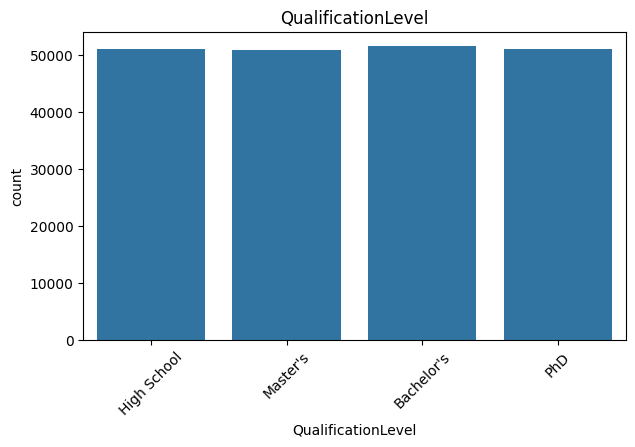

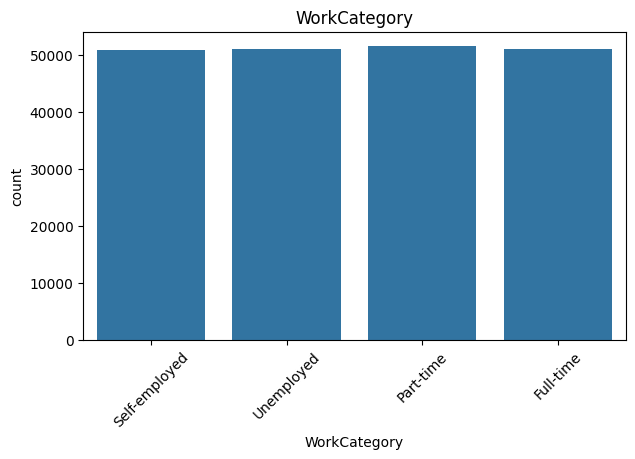

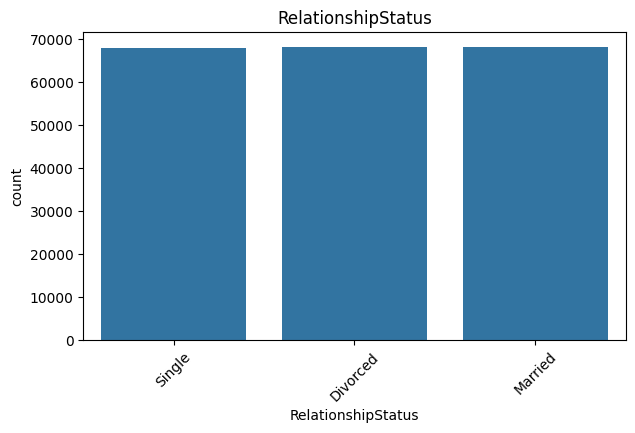

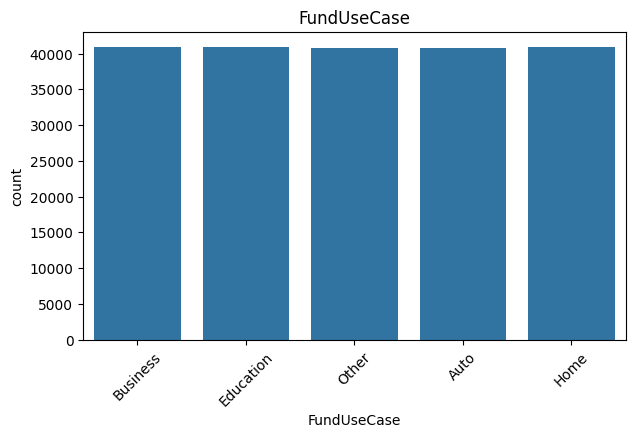

In [7]:
categorical = [
    "QualificationLevel",
    "WorkCategory",
    "RelationshipStatus",
    "FundUseCase"
]

for col in categorical:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

### Compare default rates across categories (RiskFlag vs categories)

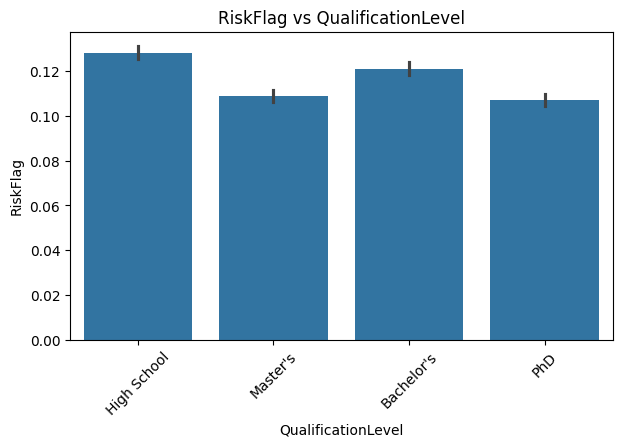

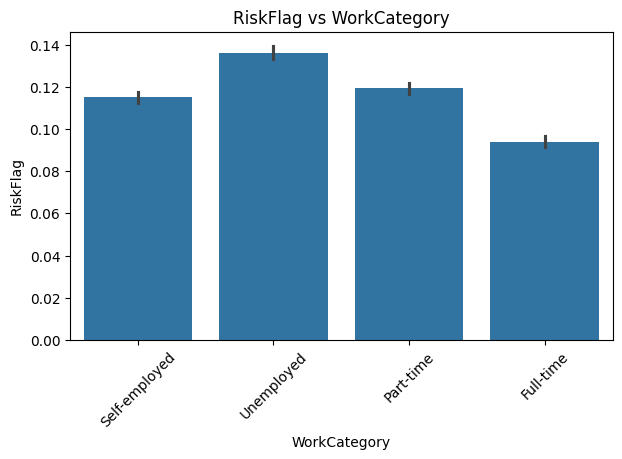

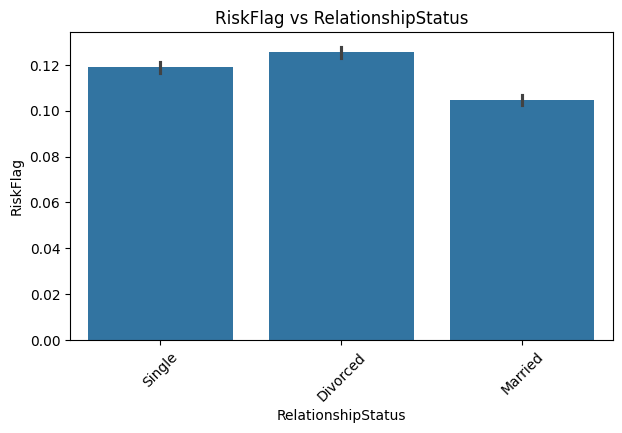

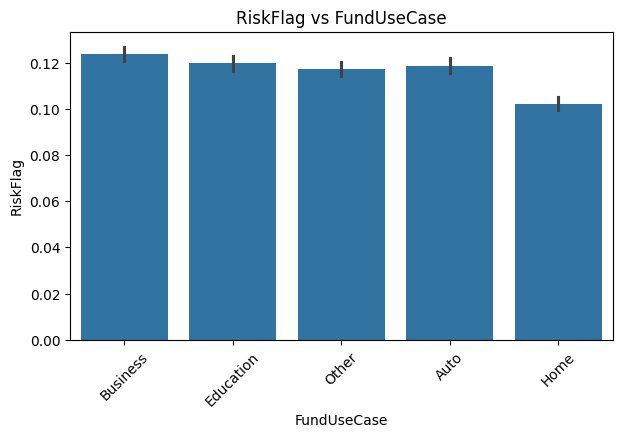

In [8]:
categorical = [
    "QualificationLevel",
    "WorkCategory",
    "RelationshipStatus",
    "FundUseCase"
]

for col in categorical:
    plt.figure(figsize=(7,4))
    sns.barplot(data=df, x=col, y="RiskFlag")
    plt.xticks(rotation=45)
    plt.title(f"RiskFlag vs {col}")
    plt.show()

### Drop ID column (not useful for prediction)

In [9]:
df = df.drop("ProfileID", axis =1)
df.head()

,ApplicantYears,AnnualEarnings,RequestedSum,TrustMetric,WorkDuration,ActiveAccounts,OfferRate,RepayPeriod,DebtFactor,QualificationLevel,WorkCategory,RelationshipStatus,OwnsProperty,FamilyObligation,FundUseCase,JointApplicant,RiskFlag
0,18,137576,209136,846,26,2,10.470,60,0.810,High School,Self-employed,Single,Yes,No,Business,No,0
1,47,57194,5970,748,30,2,19.720,36,0.730,High School,Unemployed,Divorced,No,Yes,Education,No,0
2,26,84328,95065,453,7,2,24.250,12,0.450,Master's,Self-employed,Married,No,No,Other,Yes,0
3,53,49795,229582,533,107,3,14.440,60,0.170,Bachelor's,Self-employed,Single,Yes,No,Auto,Yes,1
4,49,115450,22072,840,0,4,24.480,12,0.110,Bachelor's,Part-time,Single,No,Yes,Education,Yes,0


### Identify numerical and categorical columns

In [10]:
numerical = [
    "ApplicantYears", "AnnualEarnings", "RequestedSum", "TrustMetric",
    "WorkDuration", "ActiveAccounts", "OfferRate", "RepayPeriod", "DebtFactor"
]

categorical = [
    "QualificationLevel", "WorkCategory",
    "RelationshipStatus", "FundUseCase"
]

binary_cols = ["OwnsProperty", "FamilyObligation", "JointApplicant"]

numerical, categorical, binary_cols


(['ApplicantYears',
  'AnnualEarnings',
  'RequestedSum',
  'TrustMetric',
  'WorkDuration',
  'ActiveAccounts',
  'OfferRate',
  'RepayPeriod',
  'DebtFactor'],
 ['QualificationLevel', 'WorkCategory', 'RelationshipStatus', 'FundUseCase'],
 ['OwnsProperty', 'FamilyObligation', 'JointApplicant'])

### Convert Binary(Yes/No) columns to (0/1)

In [11]:
binary_mapping = {"Yes": 1, "No": 0}

df["OwnsProperty"] = df["OwnsProperty"].map(binary_mapping)
df["FamilyObligation"] = df["FamilyObligation"].map(binary_mapping)
df["JointApplicant"] = df["JointApplicant"].map(binary_mapping)

df[binary_cols].head()

,OwnsProperty,FamilyObligation,JointApplicant
0,1,0,0
1,0,1,0
2,0,0,1
3,1,0,1
4,0,1,1


### One-hot encode categorical features

In [12]:
df = pd.get_dummies(df, columns=categorical, drop_first=True)
df.head()

,ApplicantYears,AnnualEarnings,RequestedSum,TrustMetric,WorkDuration,ActiveAccounts,OfferRate,RepayPeriod,DebtFactor,OwnsProperty,FamilyObligation,JointApplicant,RiskFlag,QualificationLevel_High School,QualificationLevel_Master's,QualificationLevel_PhD,WorkCategory_Part-time,WorkCategory_Self-employed,WorkCategory_Unemployed,RelationshipStatus_Married,RelationshipStatus_Single,FundUseCase_Business,FundUseCase_Education,FundUseCase_Home,FundUseCase_Other
0,18,137576,209136,846,26,2,10.470,60,0.810,1,0,0,0,True,False,False,False,True,False,False,True,True,False,False,False
1,47,57194,5970,748,30,2,19.720,36,0.730,0,1,0,0,True,False,False,False,False,True,False,False,False,True,False,False
2,26,84328,95065,453,7,2,24.250,12,0.450,0,0,1,0,False,True,False,False,True,False,True,False,False,False,False,True
3,53,49795,229582,533,107,3,14.440,60,0.170,1,0,1,1,False,False,False,False,True,False,False,True,False,False,False,False
4,49,115450,22072,840,0,4,24.480,12,0.110,0,1,1,0,False,False,False,True,False,False,False,True,False,True,False,False


### Scale numerical features for SVM and Neural Network

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numerical] = scaler.fit_transform(df[numerical])

df.head()

,ApplicantYears,AnnualEarnings,RequestedSum,TrustMetric,WorkDuration,ActiveAccounts,OfferRate,RepayPeriod,DebtFactor,OwnsProperty,FamilyObligation,JointApplicant,RiskFlag,QualificationLevel_High School,QualificationLevel_Master's,QualificationLevel_PhD,WorkCategory_Part-time,WorkCategory_Self-employed,WorkCategory_Unemployed,RelationshipStatus_Married,RelationshipStatus_Single,FundUseCase_Business,FundUseCase_Education,FundUseCase_Home,FundUseCase_Other
0,-1.700,1.414,1.151,1.712,-0.967,-0.450,-0.455,1.416,1.340,1,0,0,0,True,False,False,False,True,False,False,True,True,False,False,False
1,0.234,-0.650,-1.716,1.095,-0.852,-0.450,0.939,-0.001,0.994,0,1,0,0,True,False,False,False,False,True,False,False,False,True,False,False
2,-1.166,0.047,-0.458,-0.762,-1.516,-0.450,1.622,-1.417,-0.219,0,0,1,0,False,True,False,False,True,False,True,False,False,False,False,True
3,0.634,-0.840,1.440,-0.259,1.371,0.446,0.143,1.416,-1.432,1,0,1,1,False,False,False,False,True,False,False,True,False,False,False,False
4,0.367,0.846,-1.489,1.674,-1.718,1.341,1.656,-1.417,-1.691,0,1,1,0,False,False,False,True,False,False,False,True,False,True,False,False


### Split dataset into features (X) and target (y)

In [14]:
X = df.drop("RiskFlag", axis=1)
y = df["RiskFlag"]

### Train-test split (80% train, 20% test)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Train Logistic Regression Classifier

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(max_iter = 500)
log_reg.fit(X_train, y_train)

log_preds = log_reg.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, log_preds))
print("\nClassification Report:\n", classification_report(y_test, log_preds))

Accuracy:  0.8847904836498923

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     36105
           1       0.57      0.04      0.07      4751

    accuracy                           0.88     40856
   macro avg       0.73      0.52      0.50     40856
weighted avg       0.85      0.88      0.84     40856



### Train Logistic Regression with class weights to handle imbalance

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg_balanced = LogisticRegression(class_weight='balanced', max_iter=500)
log_reg_balanced.fit(X_train, y_train)

log_bal_preds = log_reg_balanced.predict(X_test)

print("Accuracy:", accuracy_score(y_test, log_bal_preds))
print("\nClassification Report:\n", classification_report(y_test, log_bal_preds))

Accuracy: 0.6711866066183669

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.67      0.78     36105
           1       0.22      0.69      0.33      4751

    accuracy                           0.67     40856
   macro avg       0.58      0.68      0.56     40856
weighted avg       0.86      0.67      0.73     40856



### Train Linear SVM classifier (handles high-dimensional data efficiently)

In [18]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

linear_svm = LinearSVC(class_weight='balanced', max_iter=5000)
linear_svm.fit(X_train, y_train)

lin_svm_preds = linear_svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lin_svm_preds))
print("\nClassification Report:\n", classification_report(y_test, lin_svm_preds))

Accuracy: 0.6690327002153906

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.67      0.78     36105
           1       0.21      0.70      0.33      4751

    accuracy                           0.67     40856
   macro avg       0.58      0.68      0.55     40856
weighted avg       0.86      0.67      0.73     40856



### Train a Neural Network (MLPClassifier) on the full dataset


In [19]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

print("Training Neural Network...")
start = time.time()

nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # Two hidden layers
    activation='relu',
    solver='adam',
    alpha=1e-4,                     # L2 regularization
    learning_rate='adaptive',
    max_iter=20,                    # Keep small to control time
    early_stopping=True,            # Stops if no improvement
    random_state=42
)

nn_model.fit(X_train, y_train)

print("Training time:", time.time() - start, "seconds")

nn_preds = nn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nn_preds))
print("\nClassification Report:\n", classification_report(y_test, nn_preds))

Training Neural Network...
Training time: 16.813297510147095 seconds
Accuracy: 0.8858429606422558

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     36105
           1       0.58      0.07      0.12      4751

    accuracy                           0.89     40856
   macro avg       0.73      0.53      0.53     40856
weighted avg       0.85      0.89      0.84     40856



### Install imbalanced-learn for oversampling


In [25]:
!pip install imbalanced-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 2.9 MB/s eta 0:00:002.4 MB/s eta 0:00:01


### Oversample minority class before training Neural Network


In [26]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print("Original:", y_train.value_counts())
print("Resampled:", y_train_resampled.value_counts())


Original: RiskFlag
0    144419
1     19002
Name: count, dtype: int64
Resampled: RiskFlag
0    144419
1    144419
Name: count, dtype: int64


### Train Neural Network on oversampled balanced dataset


In [29]:
print("Training Neural Network on oversampled data...")
start = time.time()

nn_model2 = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate='adaptive',
    max_iter=200,              # balanced training converges faster
    early_stopping=True,
    random_state=42
)

nn_model2.fit(X_train_resampled, y_train_resampled)

print("Training time:", time.time() - start, "seconds")

nn2_preds = nn_model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nn2_preds))
print("\nClassification Report:\n", classification_report(y_test, nn2_preds))


Training Neural Network on oversampled data...
Training time: 413.208637714386 seconds
Accuracy: 0.8028196592911689

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89     36105
           1       0.22      0.27      0.24      4751

    accuracy                           0.80     40856
   macro avg       0.56      0.57      0.56     40856
weighted avg       0.82      0.80      0.81     40856

